In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [140]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [141]:
# Percentage of missing values in each column
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [142]:
df.shape

(19158, 13)

In [143]:
# Selecting columns with missing values less than 5% and greater than 0%
# var for var means -> for var in df.columns: cols.append(var)
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [144]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8455,0.764,Part time course,Graduate,5.0,78.0
724,0.794,Full time course,Masters,15.0,33.0
5122,0.766,no_enrollment,Graduate,1.0,19.0
5358,0.512,no_enrollment,Masters,9.0,68.0
6530,0.920,no_enrollment,Graduate,20.0,35.0


In [145]:
# Can calculate the percentage of Data available after dropping the rows with missing values in the selected columns
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [146]:
new_df = df[cols].dropna()
new_df.shape, df.shape

((17182, 5), (19158, 13))

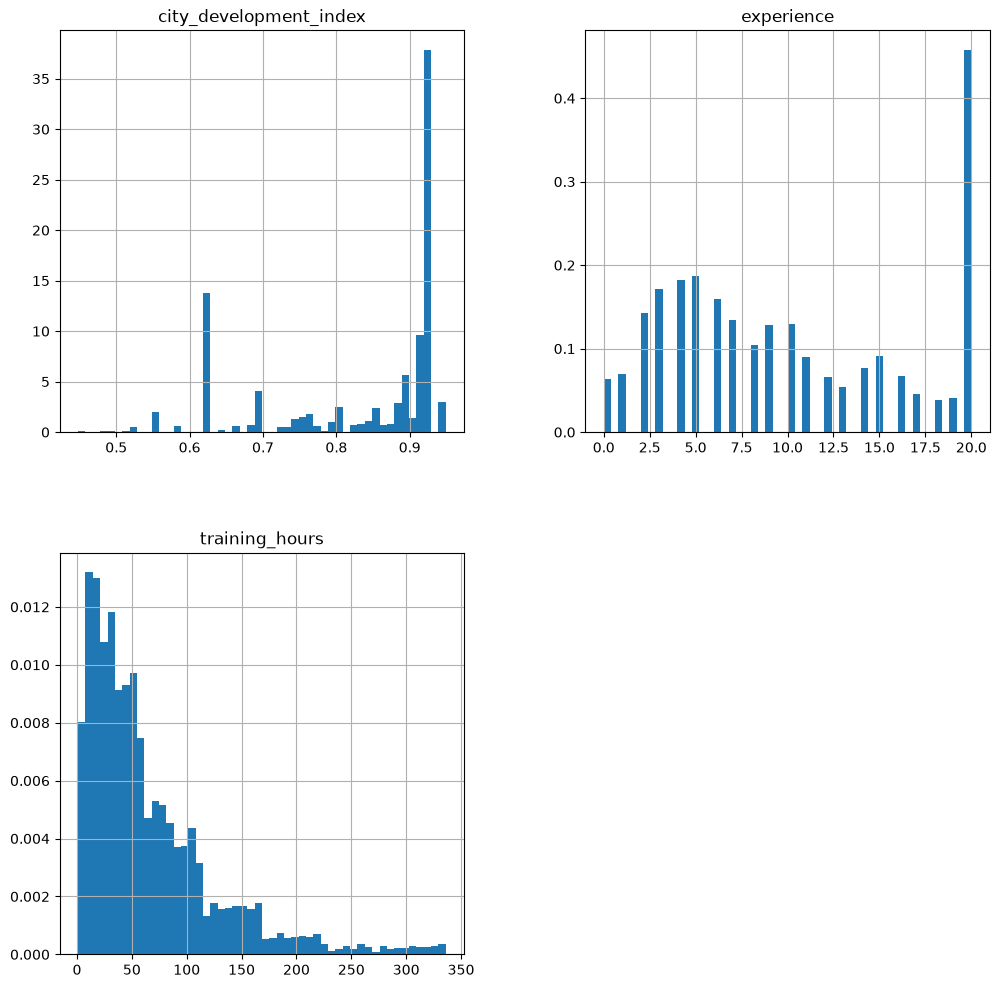

In [147]:
# Visualizing the distribution of the data after dropping the rows with missing values
new_df.hist(bins=50, density=True, figsize=(12,12))
plt.show()

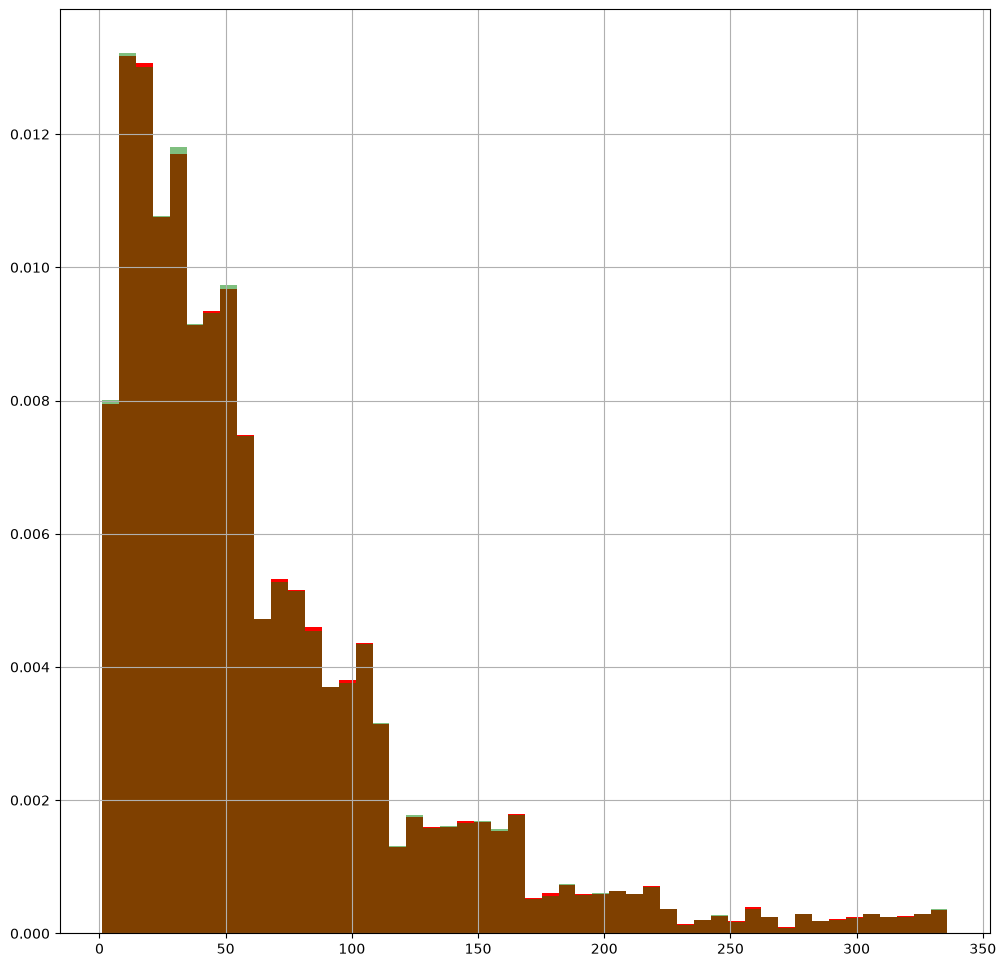

In [148]:
# Visualizing the distribution of the data before dropping the rows with missing values for training_hours column
fig = plt.figure()
ax = fig.add_subplot(111)

# original data distribution
df['training_hours'].hist(bins=50, density=True, figsize=(12,12), ax=ax, color='red')

# Data after CCA distribution
new_df['training_hours'].hist(bins=50, density=True, figsize=(12,12), alpha=0.5, ax=ax, color='green')

plt.show()


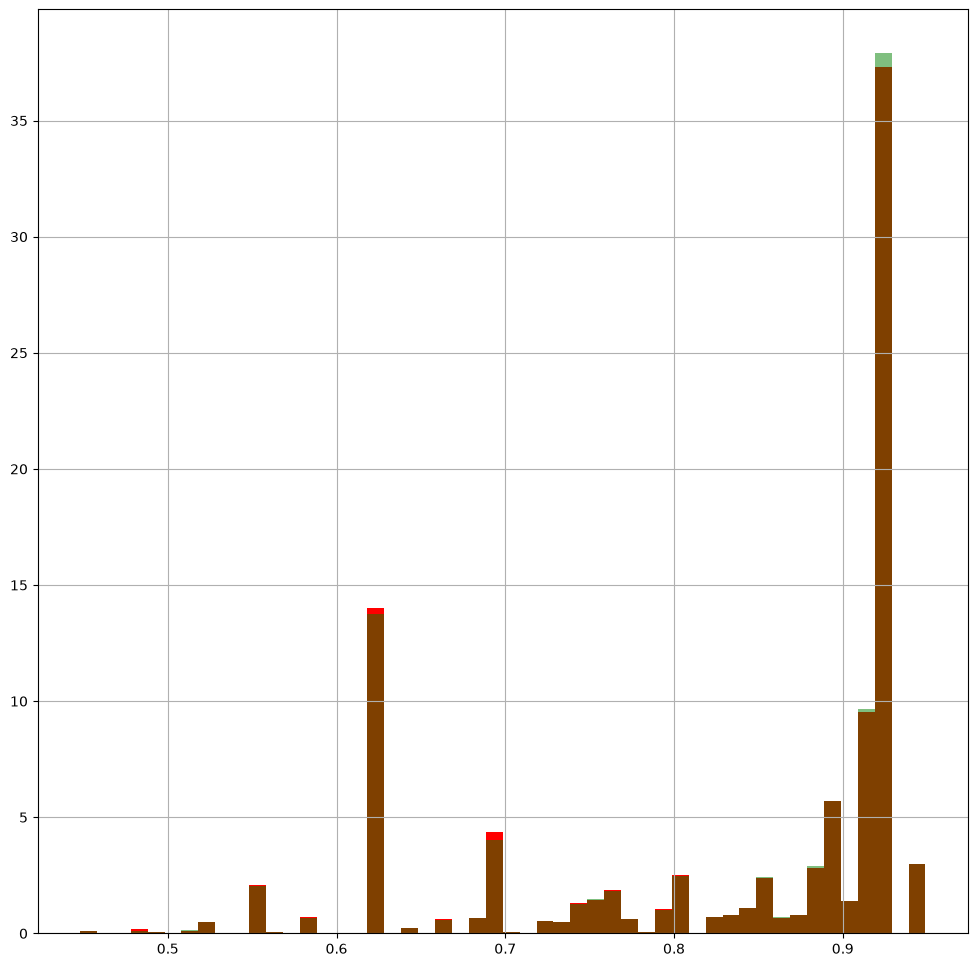

In [149]:
# Visualizing the distribution of the data before dropping the rows with missing values for city_development_index column
fig = plt.figure()
ax = fig.add_subplot(111)

# original data distribution
df['city_development_index'].hist(bins=50, density=True, figsize=(12,12), ax=ax, color='red')


# Data after CCA distribution
new_df['city_development_index'].hist(bins=50, density=True, figsize=(12,12), alpha=0.5, ax=ax, color='green')

plt.show()

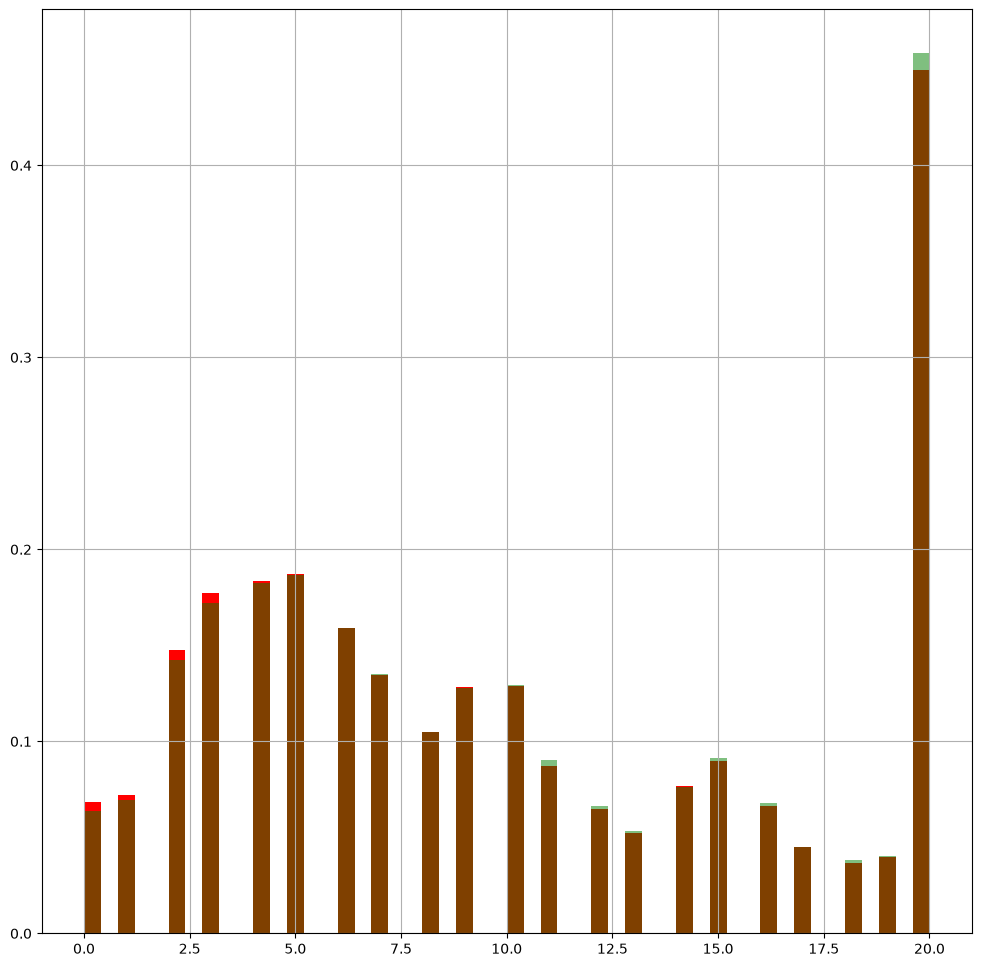

In [150]:
# Visualizing the distribution of the data before dropping the rows with missing values for experience column
fig = plt.figure()
ax = fig.add_subplot(111)

# original data distribution
df['experience'].hist(bins=50, density=True, figsize=(12,12), ax=ax, color='red')

# Data after CCA distribution
new_df['experience'].hist(bins=50, density=True, figsize=(12,12), alpha=0.5, ax=ax, color='green')

plt.show()

In [151]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [152]:
new_df['education_level'].value_counts()

education_level
Graduate          10650
Masters            4022
High School        1845
Phd                 380
Primary School      285
Name: count, dtype: int64

In [ ]:
# Checking Frequency before and after CCA
temp = pd.concat([df['education_level'].value_counts() / len(df), new_df['education_level'].value_counts()/ len(new_df)], axis=1)
temp.columns = ['Before CCA', 'After CCA']
temp

,Before CCA,After CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
